In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.datasets import fetch_california_housing

In [3]:
housing_data = fetch_california_housing()
housing_data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [5]:
df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)
df["target"] = housing_data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
x_train, x_test, y_train, y_test = train_test_split(housing_data.data, housing_data.target)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((15480, 8), (5160, 8), (15480,), (5160,))

In [7]:
housing_data.data.shape

(20640, 8)

# Creare de model

In [8]:
model_1 = tf.keras.Sequential([


    ## Input este neschimbabil
    tf.keras.layers.Input(shape=(8,)),

    ## LAYERE dense sunt variabile
    ## Cea mai buna practica este activarea relu
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),


    ## Output este neschimbabil
    tf.keras.layers.Dense(1)

    ])

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
64 * 8 + 64

576

In [10]:
64 * 32 + 32

2080

In [ ]:
# model_1.compile(loss="mse", optimizer="adam", metrics=["mae"])

In [12]:
model_1.compile(loss=tf.keras.losses.mse, optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=["mae"])


In [13]:
model_1.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 69.6846 - mae: 3.1692 - val_loss: 13.6286 - val_mae: 0.9359
Epoch 2/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 5.0616 - mae: 1.3395 - val_loss: 2.4285 - val_mae: 0.9463
Epoch 3/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.7648 - mae: 0.9507 - val_loss: 3.6009 - val_mae: 1.4612
Epoch 4/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 124.5238 - mae: 3.4775 - val_loss: 24.1966 - val_mae: 3.8726
Epoch 5/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.0367 - mae: 0.9734 - val_loss: 1.0120 - val_mae: 0.7432
Epoch 6/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.0130 - mae: 0.9078 - val_loss: 1.1105 - val_mae: 0.7853
Epoch 7/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.1599 - mae: 1.0871 - val_loss: 1.1382 - val_mae: 0.8658
Epoch 8/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4256 - mae: 0.8753 - val_loss: 1.0658 - val_mae: 0.7600
Epoch 9/10
484/484 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

In [19]:
model_version = model_1

def plot_history(model_version):
      loss = model_version.history.history["loss"]
      val_loss = model_version.history.history["val_loss"]
      mae = model_version.history.history["mae"]
      val_mae = model_version.history.history["val_mae"]
      plt.plot(loss)
      plt.plot(val_loss)
      plt.title("Loss vs Val_loss ")
      plt.xlabel("Epoci")
      plt.legend(["Training Data", "Validation Data"])
      plt.show()

      plt.plot(mae)
      plt.plot(val_mae)
      plt.title("mae vs Val_mae ")
      plt.xlabel("Epoci")
      plt.legend(["Training Data", "Validation Data"])
      plt.show()

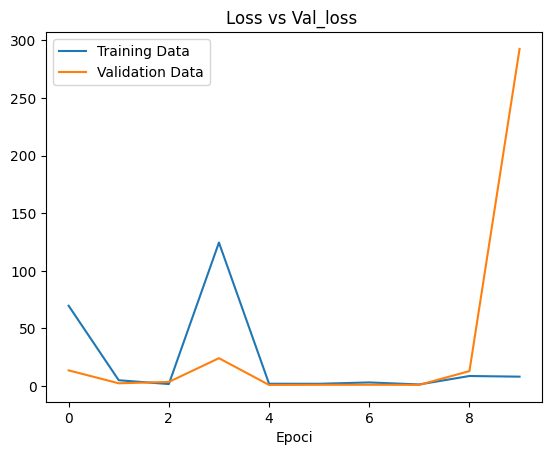

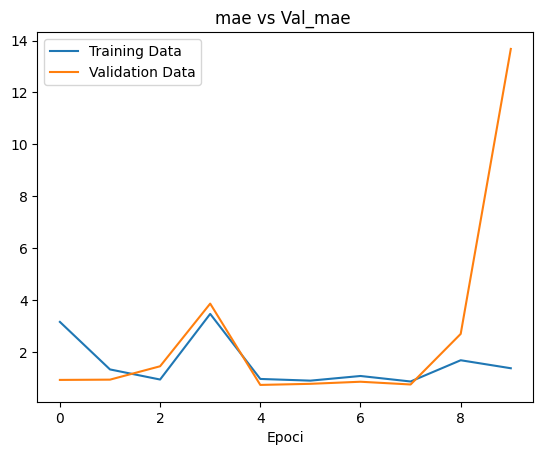

In [20]:
plot_history(model_1)

In [21]:
model_2 = tf.keras.Sequential([


    ## Input este neschimbabil
    tf.keras.layers.Input(shape=(8,)),

    ## LAYERE dense sunt variabile
    ## Cea mai buna practica este activarea relu
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),


    ## Output este neschimbabil
    tf.keras.layers.Dense(1)

    ])

model_2.summary()
model_2.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=["mae", "RootMeanSquaredError"])
model_2.fit(x_train, y_train, epochs=20, validation_split=0.2, verbose=0)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)

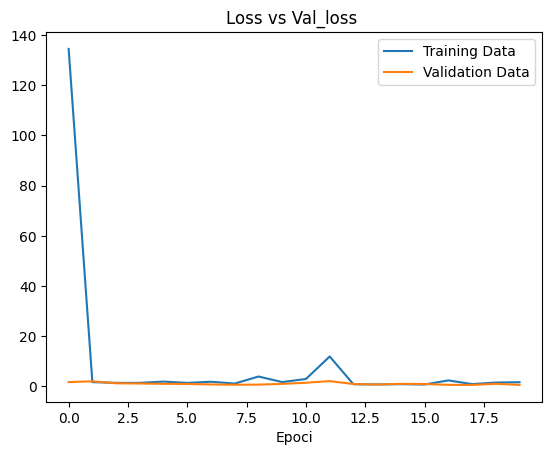

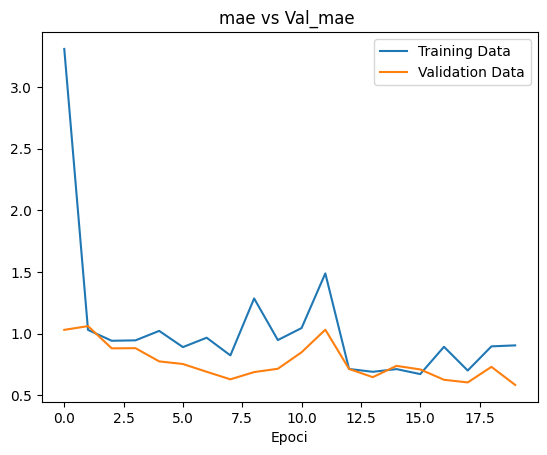

In [22]:
plot_history(model_2)

In [23]:
model_2.evaluate(x_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - RootMeanSquaredError: 0.8089 - loss: 0.6543 - mae: 0.5972


[0.6543442606925964, 0.5971983075141907, 0.8089154958724976]

In [24]:
model_3 = tf.keras.Sequential([


    ## Input este neschimbabil
    tf.keras.layers.Input(shape=(8,)),

    ## LAYERE dense sunt variabile
    ## Cea mai buna practica este activarea relu
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.2),


    ## Output este neschimbabil
    tf.keras.layers.Dense(1)

    ])

model_3.summary()
model_3.compile(loss="mse", optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=["mae", "RootMeanSquaredError"])
model_3.fit(x_train, y_train, epochs=20, validation_split=0.2, verbose=0)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,849 (26.75 KB)

 Trainable params: 6,849 (26.75 KB)

 Non-trainable params: 0 (0.00 B)